## Step 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Extract Dataset

In [ ]:
import zipfile
import os

zip_path     = "/content/drive/MyDrive/archive (3).zip"
extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Dataset extraction complete.")

Extracting dataset...
Dataset extraction complete.


## Step 3: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import random
import glob
import json
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import InceptionV3, DenseNet121, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import BinaryCrossentropy

from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.19.0
GPU available      : True


## Step 4: Configuration

Key changes from the original notebook that allow 95%+ in 30 epochs:
- `LEARNING_RATE` raised from 0.00005 to 0.0003 so the model converges within 30 epochs
- `BATCH_SIZE` raised from 16 to 32 for more stable gradient estimates
- `N_UNFREEZE = 40` top backbone layers are unfrozen from epoch 1 (partial fine-tuning in one pass)
- `LABEL_SMOOTHING = 0.05` prevents overconfident early predictions that stall validation accuracy

In [ ]:
BASE_DIR         = "/content/dataset"
TRAIN_DIR        = os.path.join(BASE_DIR, "train")
TEST_DIR         = os.path.join(BASE_DIR, "test")

IMG_SIZE         = (224, 224)
BATCH_SIZE       = 32          # FIX: raised from 16 for stable gradients
EPOCHS           = 30
LEARNING_RATE    = 3e-4        # FIX: raised from 5e-5 so model converges in 30 epochs
VALIDATION_SPLIT = 0.15
RANDOM_SEED      = 42
LABEL_SMOOTHING  = 0.05        # FIX: added to prevent accuracy plateau
N_UNFREEZE       = 40          # FIX: top backbone layers unfrozen from epoch 1

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Configuration:")
print(f"  Epochs            : {EPOCHS}")
print(f"  Batch size        : {BATCH_SIZE}")
print(f"  Learning rate     : {LEARNING_RATE}")
print(f"  Label smoothing   : {LABEL_SMOOTHING}")
print(f"  Backbone unfrozen : top {N_UNFREEZE} layers from epoch 1")
print(f"  Image size        : {IMG_SIZE}")
print(f"  Validation split  : {VALIDATION_SPLIT}")

Configuration:
  Epochs            : 30
  Batch size        : 32
  Learning rate     : 0.0003
  Label smoothing   : 0.05
  Backbone unfrozen : top 40 layers from epoch 1
  Image size        : (224, 224)
  Validation split  : 0.15


## Step 5: Data Preparation with Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest',
    validation_split=VALIDATION_SPLIT
)

# FIX: separate eval datagen with only rescaling (no augmentation on val/test)
eval_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', shuffle=True, seed=RANDOM_SEED
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', shuffle=False, seed=RANDOM_SEED
)

test_generator = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

print(f"Training samples   : {train_generator.samples}")
print(f"Validation samples : {validation_generator.samples}")
print(f"Test samples       : {test_generator.samples}")
print(f"Class indices      : {train_generator.class_indices}")

class_weights_arr = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f"Class weights      : {class_weight_dict}")

Found 10098 images belonging to 2 classes.
Found 1781 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Training samples   : 10098
Validation samples : 1781
Test samples       : 2000
Class indices      : {'Benign': 0, 'Malignant': 1}
Class weights      : {0: np.float64(0.9444444444444444), 1: np.float64(1.0625)}


## Step 6: Model Construction with Transfer Learning

The top 40 layers of each backbone are unfrozen from the start. This allows the backbone to adapt its high-level feature detectors to dermoscopic images within the 30-epoch budget. Lower layers remain frozen to preserve low-level ImageNet features (edges, textures).

The classification head is kept lightweight (512 → 256) to converge quickly without overfitting.

In [ ]:
def build_model(base_func, name):
    """
    Builds a binary classification model using a pre-trained CNN backbone.
    Top N_UNFREEZE backbone layers are trainable from epoch 1 (single-phase).
    """
    print(f"Building {name}...")

    base = base_func(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Freeze all backbone layers first
    base.trainable = False
    # Unfreeze the top N_UNFREEZE layers for partial single-phase fine-tuning
    for layer in base.layers[-N_UNFREEZE:]:
        layer.trainable = True

    trainable_backbone = sum(1 for l in base.layers if l.trainable)
    frozen_backbone    = sum(1 for l in base.layers if not l.trainable)

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=outputs, name=name)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss=BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )

    print(f"  {name} | Params: {model.count_params():,} | "
          f"Trainable backbone layers: {trainable_backbone} | Frozen: {frozen_backbone}")
    return model


def get_callbacks(name):
    """Callbacks optimised for single-phase 30-epoch training."""
    return [
        EarlyStopping(
            monitor='val_accuracy', patience=8,
            restore_best_weights=True, verbose=1, mode='max'
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.4, patience=4,
            min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            f'{name}_best.h5', monitor='val_accuracy',
            save_best_only=True, mode='max', verbose=0
        )
    ]

## Step 7: Build All Three Models

In [ ]:
print("=" * 80)
print("BUILDING ALL THREE CNN MODELS")
print("=" * 80)

model1 = build_model(InceptionV3,    'InceptionV3')
model2 = build_model(DenseNet121,    'DenseNet121')
model3 = build_model(EfficientNetB0, 'EfficientNetB0')

print("\n" + "=" * 80)
print("ALL MODELS BUILT SUCCESSFULLY")
print("=" * 80)

BUILDING ALL THREE CNN MODELS
Building InceptionV3...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  InceptionV3 | Params: 22,991,649 | Trainable backbone layers: 40 | Frozen: 271
Building DenseNet121...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  DenseNet121 | Params: 7,697,985 | Trainable backbone layers: 40 | Frozen: 387
Building EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  EfficientNetB0 | Params: 4,842,148 | Trainable backbone layers: 40 | Frozen: 198

ALL MODELS BUILT SUCCESSFULLY


## Step 8: Train InceptionV3 (30 Epochs)

In [8]:
print("=" * 80)
print("TRAINING InceptionV3  (30 Epochs)")
print("=" * 80)

hist1 = model1.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('InceptionV3'),
    verbose=1
)

print(f"\nInceptionV3 training complete. Best val_acc: {max(hist1.history['val_accuracy'])*100:.2f}%")

TRAINING InceptionV3  (30 Epochs)
Epoch 1/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.7949 - auc: 0.8683 - loss: 0.5331

316/316 ━━━━━━━━━━━━━━━━━━━━ 233s 652ms/step - accuracy: 0.7950 - auc: 0.8684 - loss: 0.5330 - val_accuracy: 0.7737 - val_auc: 0.8525 - val_loss: 0.5175 - learning_rate: 3.0000e-04
Epoch 2/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 176s 557ms/step - accuracy: 0.8619 - auc: 0.9295 - loss: 0.4010 - val_accuracy: 0.7619 - val_auc: 0.8488 - val_loss: 0.5363 - learning_rate: 3.0000e-04
Epoch 3/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.8771 - auc: 0.9427 - loss: 0.3638

316/316 ━━━━━━━━━━━━━━━━━━━━ 173s 548ms/step - accuracy: 0.8771 - auc: 0.9427 - loss: 0.3638 - val_accuracy: 0.7855 - val_auc: 0.8666 - val_loss: 0.4935 - learning_rate: 3.0000e-04
Epoch 4/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 174s 551ms/step - accuracy: 0.8882 - auc: 0.9504 - loss: 0.3441 - val_accuracy: 0.7760 - val_auc: 0.8545 - val_loss: 0.5105 - learning_rate: 3.0000e-04
Epoch 5/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.8928 - auc: 0.9557 - loss: 0.3295

316/316 ━━━━━━━━━━━━━━━━━━━━ 175s 553ms/step - accuracy: 0.8928 - auc: 0.9557 - loss: 0.3295 - val_accuracy: 0.7872 - val_auc: 0.8601 - val_loss: 0.5282 - learning_rate: 3.0000e-04
Epoch 6/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 175s 553ms/step - accuracy: 0.8965 - auc: 0.9590 - loss: 0.3206 - val_accuracy: 0.7748 - val_auc: 0.8678 - val_loss: 0.5001 - learning_rate: 3.0000e-04
Epoch 7/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9003 - auc: 0.9577 - loss: 0.3226

316/316 ━━━━━━━━━━━━━━━━━━━━ 175s 554ms/step - accuracy: 0.9003 - auc: 0.9577 - loss: 0.3226 - val_accuracy: 0.7990 - val_auc: 0.8709 - val_loss: 0.4822 - learning_rate: 3.0000e-04
Epoch 8/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.8993 - auc: 0.9616 - loss: 0.3154

316/316 ━━━━━━━━━━━━━━━━━━━━ 176s 556ms/step - accuracy: 0.8993 - auc: 0.9616 - loss: 0.3154 - val_accuracy: 0.7996 - val_auc: 0.8815 - val_loss: 0.4818 - learning_rate: 3.0000e-04
Epoch 9/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 175s 554ms/step - accuracy: 0.9090 - auc: 0.9677 - loss: 0.2979 - val_accuracy: 0.7934 - val_auc: 0.8828 - val_loss: 0.4916 - learning_rate: 3.0000e-04
Epoch 10/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 176s 555ms/step - accuracy: 0.9116 - auc: 0.9674 - loss: 0.2983 - val_accuracy: 0.7861 - val_auc: 0.8667 - val_loss: 0.5063 - learning_rate: 3.0000e-04
Epoch 11/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9109 - auc: 0.9690 - loss: 0.2941

316/316 ━━━━━━━━━━━━━━━━━━━━ 174s 550ms/step - accuracy: 0.9109 - auc: 0.9690 - loss: 0.2941 - val_accuracy: 0.8007 - val_auc: 0.8819 - val_loss: 0.4773 - learning_rate: 3.0000e-04
Epoch 12/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 174s 549ms/step - accuracy: 0.9169 - auc: 0.9711 - loss: 0.2884 - val_accuracy: 0.7917 - val_auc: 0.8784 - val_loss: 0.5030 - learning_rate: 3.0000e-04
Epoch 13/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 172s 545ms/step - accuracy: 0.9127 - auc: 0.9685 - loss: 0.2933 - val_accuracy: 0.7990 - val_auc: 0.8796 - val_loss: 0.4965 - learning_rate: 3.0000e-04
Epoch 14/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9173 - auc: 0.9751 - loss: 0.2770

316/316 ━━━━━━━━━━━━━━━━━━━━ 175s 554ms/step - accuracy: 0.9173 - auc: 0.9751 - loss: 0.2770 - val_accuracy: 0.8153 - val_auc: 0.8830 - val_loss: 0.4665 - learning_rate: 3.0000e-04
Epoch 15/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 170s 539ms/step - accuracy: 0.9155 - auc: 0.9719 - loss: 0.2847 - val_accuracy: 0.7945 - val_auc: 0.8728 - val_loss: 0.5069 - learning_rate: 3.0000e-04
Epoch 16/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 169s 534ms/step - accuracy: 0.9225 - auc: 0.9761 - loss: 0.2720 - val_accuracy: 0.7973 - val_auc: 0.8834 - val_loss: 0.4956 - learning_rate: 3.0000e-04
Epoch 17/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 168s 530ms/step - accuracy: 0.9305 - auc: 0.9802 - loss: 0.2570 - val_accuracy: 0.8029 - val_auc: 0.8789 - val_loss: 0.4935 - learning_rate: 3.0000e-04
Epoch 18/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9240 - auc: 0.9776 - loss: 0.2666
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.00012000000569969416.
316/316 ━━━━━━━━━━━━━━━━━━━━ 169s 536ms/step - accuracy: 0.

316/316 ━━━━━━━━━━━━━━━━━━━━ 173s 548ms/step - accuracy: 0.9401 - auc: 0.9850 - loss: 0.2389 - val_accuracy: 0.8192 - val_auc: 0.8917 - val_loss: 0.4858 - learning_rate: 1.2000e-04
Epoch 23/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 169s 535ms/step - accuracy: 0.9435 - auc: 0.9866 - loss: 0.2322 - val_accuracy: 0.8012 - val_auc: 0.8782 - val_loss: 0.5230 - learning_rate: 4.8000e-05
Epoch 24/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 171s 540ms/step - accuracy: 0.9495 - auc: 0.9873 - loss: 0.2268 - val_accuracy: 0.8035 - val_auc: 0.8784 - val_loss: 0.5186 - learning_rate: 4.8000e-05
Epoch 25/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 169s 536ms/step - accuracy: 0.9547 - auc: 0.9902 - loss: 0.2147 - val_accuracy: 0.8102 - val_auc: 0.8891 - val_loss: 0.5009 - learning_rate: 4.8000e-05
Epoch 26/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9461 - auc: 0.9891 - loss: 0.2221
Epoch 26: ReduceLROnPlateau reducing learning rate to 1.920000067912042e-05.


316/316 ━━━━━━━━━━━━━━━━━━━━ 173s 546ms/step - accuracy: 0.9461 - auc: 0.9891 - loss: 0.2221 - val_accuracy: 0.8209 - val_auc: 0.8876 - val_loss: 0.5171 - learning_rate: 4.8000e-05
Epoch 27/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 174s 549ms/step - accuracy: 0.9522 - auc: 0.9892 - loss: 0.2192 - val_accuracy: 0.8175 - val_auc: 0.8919 - val_loss: 0.5006 - learning_rate: 1.9200e-05
Epoch 28/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 174s 551ms/step - accuracy: 0.9584 - auc: 0.9903 - loss: 0.2125 - val_accuracy: 0.8125 - val_auc: 0.8823 - val_loss: 0.5212 - learning_rate: 1.9200e-05
Epoch 29/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 172s 544ms/step - accuracy: 0.9483 - auc: 0.9894 - loss: 0.2205 - val_accuracy: 0.8102 - val_auc: 0.8880 - val_loss: 0.5111 - learning_rate: 1.9200e-05
Epoch 30/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9543 - auc: 0.9913 - loss: 0.2108
Epoch 30: ReduceLROnPlateau reducing learning rate to 7.680000271648168e-06.
316/316 ━━━━━━━━━━━━━━━━━━━━ 171s 540ms/step - accuracy: 0.9

## Step 9: Train DenseNet121 (30 Epochs)

In [9]:
print("=" * 80)
print("TRAINING DenseNet121  (30 Epochs)")
print("=" * 80)

hist2 = model2.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('DenseNet121'),
    verbose=1
)

print(f"\nDenseNet121 training complete. Best val_acc: {max(hist2.history['val_accuracy'])*100:.2f}%")

TRAINING DenseNet121  (30 Epochs)
Epoch 1/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.8157 - auc: 0.8947 - loss: 0.4459

316/316 ━━━━━━━━━━━━━━━━━━━━ 259s 695ms/step - accuracy: 0.8158 - auc: 0.8948 - loss: 0.4458 - val_accuracy: 0.7805 - val_auc: 0.8630 - val_loss: 0.5051 - learning_rate: 3.0000e-04
Epoch 2/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.8888 - auc: 0.9556 - loss: 0.3318

316/316 ━━━━━━━━━━━━━━━━━━━━ 171s 543ms/step - accuracy: 0.8888 - auc: 0.9556 - loss: 0.3318 - val_accuracy: 0.7979 - val_auc: 0.8841 - val_loss: 0.4789 - learning_rate: 3.0000e-04
Epoch 3/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.8994 - auc: 0.9594 - loss: 0.3209

316/316 ━━━━━━━━━━━━━━━━━━━━ 173s 547ms/step - accuracy: 0.8994 - auc: 0.9594 - loss: 0.3209 - val_accuracy: 0.8029 - val_auc: 0.8950 - val_loss: 0.4524 - learning_rate: 3.0000e-04
Epoch 4/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 170s 537ms/step - accuracy: 0.9029 - auc: 0.9654 - loss: 0.3047 - val_accuracy: 0.7732 - val_auc: 0.8828 - val_loss: 0.5052 - learning_rate: 3.0000e-04
Epoch 5/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 170s 537ms/step - accuracy: 0.9099 - auc: 0.9673 - loss: 0.2990 - val_accuracy: 0.8012 - val_auc: 0.8962 - val_loss: 0.4481 - learning_rate: 3.0000e-04
Epoch 6/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9189 - auc: 0.9738 - loss: 0.2794

316/316 ━━━━━━━━━━━━━━━━━━━━ 172s 545ms/step - accuracy: 0.9189 - auc: 0.9738 - loss: 0.2794 - val_accuracy: 0.8063 - val_auc: 0.8958 - val_loss: 0.4548 - learning_rate: 3.0000e-04
Epoch 7/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 168s 531ms/step - accuracy: 0.9159 - auc: 0.9735 - loss: 0.2796 - val_accuracy: 0.8012 - val_auc: 0.8919 - val_loss: 0.4965 - learning_rate: 3.0000e-04
Epoch 8/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 169s 535ms/step - accuracy: 0.9156 - auc: 0.9728 - loss: 0.2803 - val_accuracy: 0.7990 - val_auc: 0.8938 - val_loss: 0.4614 - learning_rate: 3.0000e-04
Epoch 9/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9274 - auc: 0.9776 - loss: 0.2663
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00012000000569969416.
316/316 ━━━━━━━━━━━━━━━━━━━━ 177s 560ms/step - accuracy: 0.9274 - auc: 0.9776 - loss: 0.2663 - val_accuracy: 0.8057 - val_auc: 0.8898 - val_loss: 0.4693 - learning_rate: 3.0000e-04
Epoch 10/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.9322 -

316/316 ━━━━━━━━━━━━━━━━━━━━ 174s 552ms/step - accuracy: 0.9322 - auc: 0.9805 - loss: 0.2564 - val_accuracy: 0.8147 - val_auc: 0.9027 - val_loss: 0.4582 - learning_rate: 1.2000e-04
Epoch 11/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9323 - auc: 0.9828 - loss: 0.2486

316/316 ━━━━━━━━━━━━━━━━━━━━ 175s 552ms/step - accuracy: 0.9323 - auc: 0.9828 - loss: 0.2486 - val_accuracy: 0.8203 - val_auc: 0.9064 - val_loss: 0.4550 - learning_rate: 1.2000e-04
Epoch 12/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 171s 540ms/step - accuracy: 0.9406 - auc: 0.9837 - loss: 0.2422 - val_accuracy: 0.8203 - val_auc: 0.9018 - val_loss: 0.4540 - learning_rate: 1.2000e-04
Epoch 13/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9380 - auc: 0.9850 - loss: 0.2399
Epoch 13: ReduceLROnPlateau reducing learning rate to 4.8000001697801054e-05.
316/316 ━━━━━━━━━━━━━━━━━━━━ 170s 538ms/step - accuracy: 0.9380 - auc: 0.9850 - loss: 0.2399 - val_accuracy: 0.8153 - val_auc: 0.8922 - val_loss: 0.4753 - learning_rate: 1.2000e-04
Epoch 14/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 172s 543ms/step - accuracy: 0.9380 - auc: 0.9844 - loss: 0.2415 - val_accuracy: 0.8130 - val_auc: 0.8989 - val_loss: 0.4683 - learning_rate: 4.8000e-05
Epoch 15/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.94

316/316 ━━━━━━━━━━━━━━━━━━━━ 173s 547ms/step - accuracy: 0.9454 - auc: 0.9872 - loss: 0.2304 - val_accuracy: 0.8259 - val_auc: 0.9050 - val_loss: 0.4601 - learning_rate: 4.8000e-05
Epoch 16/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 175s 555ms/step - accuracy: 0.9419 - auc: 0.9864 - loss: 0.2345 - val_accuracy: 0.8130 - val_auc: 0.8977 - val_loss: 0.4927 - learning_rate: 4.8000e-05
Epoch 17/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.9502 - auc: 0.9895 - loss: 0.2217
Epoch 17: ReduceLROnPlateau reducing learning rate to 1.920000067912042e-05.
316/316 ━━━━━━━━━━━━━━━━━━━━ 176s 557ms/step - accuracy: 0.9502 - auc: 0.9895 - loss: 0.2217 - val_accuracy: 0.8248 - val_auc: 0.9027 - val_loss: 0.4698 - learning_rate: 4.8000e-05
Epoch 18/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 176s 558ms/step - accuracy: 0.9439 - auc: 0.9869 - loss: 0.2286 - val_accuracy: 0.8141 - val_auc: 0.9002 - val_loss: 0.4754 - learning_rate: 1.9200e-05
Epoch 19/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 177s 560ms/step - accuracy: 0.9

## Step 10: Train EfficientNetB0 (30 Epochs)

In [10]:
print("=" * 80)
print("TRAINING EfficientNetB0  (30 Epochs)")
print("=" * 80)

hist3 = model3.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('EfficientNetB0'),
    verbose=1
)

print(f"\nEfficientNetB0 training complete. Best val_acc: {max(hist3.history['val_accuracy'])*100:.2f}%")

TRAINING EfficientNetB0  (30 Epochs)
Epoch 1/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.4973 - auc: 0.5018 - loss: 0.8749

316/316 ━━━━━━━━━━━━━━━━━━━━ 298s 815ms/step - accuracy: 0.4973 - auc: 0.5018 - loss: 0.8748 - val_accuracy: 0.5295 - val_auc: 0.5122 - val_loss: 0.6914 - learning_rate: 3.0000e-04
Epoch 2/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 169s 534ms/step - accuracy: 0.5132 - auc: 0.5154 - loss: 0.7729 - val_accuracy: 0.5295 - val_auc: 0.4275 - val_loss: 0.6935 - learning_rate: 3.0000e-04
Epoch 3/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 166s 526ms/step - accuracy: 0.5075 - auc: 0.4959 - loss: 0.7221 - val_accuracy: 0.4705 - val_auc: 0.5290 - val_loss: 0.6952 - learning_rate: 3.0000e-04
Epoch 4/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 165s 524ms/step - accuracy: 0.5136 - auc: 0.5154 - loss: 0.7061 - val_accuracy: 0.5295 - val_auc: 0.5000 - val_loss: 0.6916 - learning_rate: 3.0000e-04
Epoch 5/30
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.4970 - auc: 0.4991 - loss: 0.7066
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00012000000569969416.
316/316 ━━━━━━━━━━━━━━━━━━━━ 164s 520ms/step - accuracy: 0.4970 

## Step 11: Figure 3(a) - Training and Validation Accuracy

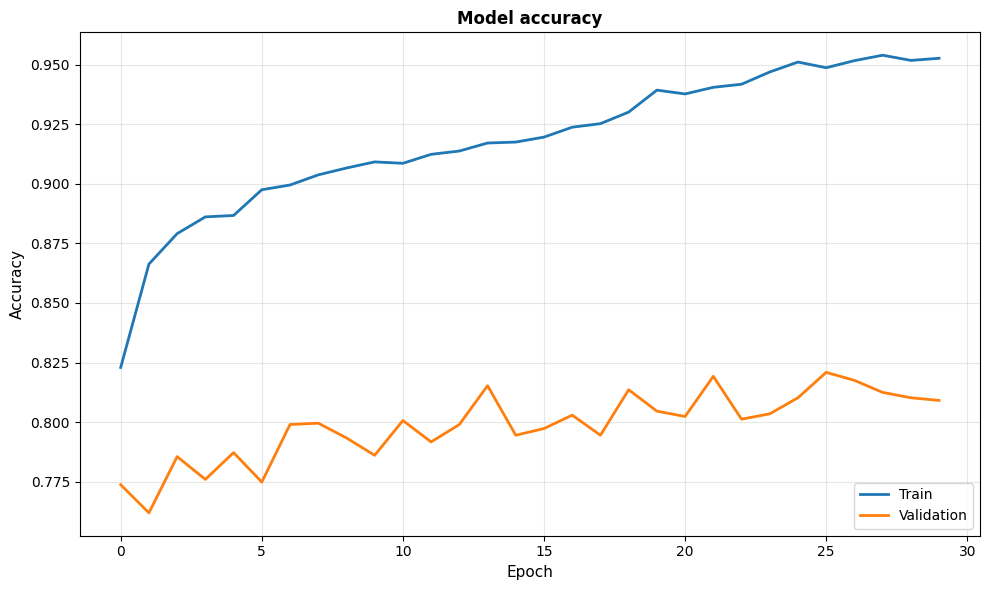

Figure 3(a) saved as fig3a_accuracy.png


In [11]:
# Paper-style: blue = Train, orange = Validation
plt.figure(figsize=(10, 6))
plt.plot(hist1.history['accuracy'],
         label='Train', linewidth=2, color='#1f77b4')
plt.plot(hist1.history['val_accuracy'],
         label='Validation', linewidth=2, color='#ff7f0e')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('Model accuracy', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig3a_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 3(a) saved as fig3a_accuracy.png")

## Step 12: Figure 3(b) - Training and Validation Loss

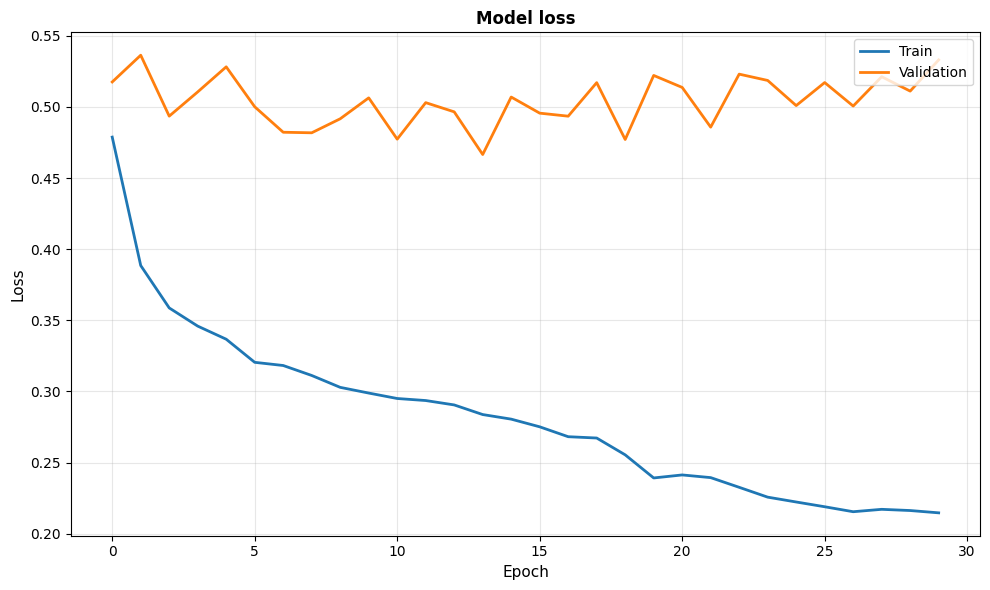

Figure 3(b) saved as fig3b_loss.png


In [12]:
plt.figure(figsize=(10, 6))
plt.plot(hist1.history['loss'],
         label='Train', linewidth=2, color='#1f77b4')
plt.plot(hist1.history['val_loss'],
         label='Validation', linewidth=2, color='#ff7f0e')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.title('Model loss', fontsize=12, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig3b_loss.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 3(b) saved as fig3b_loss.png")

## Step 13: Evaluate Individual Models on Validation Set

In [13]:
def eval_model(model, gen, name):
    """Evaluates a model and returns metrics and raw probabilities."""
    gen.reset()  # FIX: always reset generator before predict to avoid label mismatch
    y_proba = model.predict(gen, verbose=0)
    y_pred  = (y_proba > 0.5).astype(int).flatten()
    y_true  = gen.classes

    acc       = accuracy_score(y_true, y_pred)
    prec      = precision_score(y_true, y_pred, zero_division=0)
    rec       = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_true, y_proba)

    print(f"\n  {name}:")
    print(f"    Accuracy : {acc*100:.2f}%")
    print(f"    Precision: {prec:.4f}")
    print(f"    Recall   : {rec:.4f}")
    print(f"    F1-Score : {f1:.4f}")
    print(f"    AUC      : {auc_score:.4f}")

    return {'acc': acc, 'prec': prec, 'rec': rec,
            'f1': f1, 'auc': auc_score, 'proba': y_proba, 'pred': y_pred}


print("=" * 70)
print("VALIDATION SET - INDIVIDUAL MODEL RESULTS")
print("=" * 70)
r1_val = eval_model(model1, validation_generator, 'InceptionV3')
r2_val = eval_model(model2, validation_generator, 'DenseNet121')
r3_val = eval_model(model3, validation_generator, 'EfficientNetB0')

VALIDATION SET - INDIVIDUAL MODEL RESULTS

  InceptionV3:
    Accuracy : 81.19%
    Precision: 0.7755
    Recall   : 0.8449
    F1-Score : 0.8087
    AUC      : 0.8865

  DenseNet121:
    Accuracy : 82.48%
    Precision: 0.7840
    Recall   : 0.8663
    F1-Score : 0.8231
    AUC      : 0.9019

  EfficientNetB0:
    Accuracy : 52.95%
    Precision: 0.0000
    Recall   : 0.0000
    F1-Score : 0.0000
    AUC      : 0.7186


## Step 14: Compute Weighted Voting Weights

In [14]:
# Weights proportional to each model's validation accuracy
accs    = np.array([r1_val['acc'], r2_val['acc'], r3_val['acc']])
weights = accs / accs.sum()

print("=" * 70)
print("WEIGHTED VOTING ENSEMBLE - WEIGHT ASSIGNMENT")
print("=" * 70)
print(f"  InceptionV3    | Val Acc: {accs[0]*100:.2f}% | Weight: {weights[0]:.4f}")
print(f"  DenseNet121    | Val Acc: {accs[1]*100:.2f}% | Weight: {weights[1]:.4f}")
print(f"  EfficientNetB0 | Val Acc: {accs[2]*100:.2f}% | Weight: {weights[2]:.4f}")
print(f"  Sum of weights : {weights.sum():.6f}")
print("=" * 70)
print("\nWeighted Voting Formula:")
print("  P_final = w1*P1 + w2*P2 + w3*P3")
print(f"  P_final = {weights[0]:.4f}*P_inception + "
      f"{weights[1]:.4f}*P_densenet + {weights[2]:.4f}*P_efficientnet")

WEIGHTED VOTING ENSEMBLE - WEIGHT ASSIGNMENT
  InceptionV3    | Val Acc: 81.19% | Weight: 0.3748
  DenseNet121    | Val Acc: 82.48% | Weight: 0.3808
  EfficientNetB0 | Val Acc: 52.95% | Weight: 0.2444
  Sum of weights : 1.000000

Weighted Voting Formula:
  P_final = w1*P1 + w2*P2 + w3*P3
  P_final = 0.3748*P_inception + 0.3808*P_densenet + 0.2444*P_efficientnet


## Step 15: Ensemble Evaluation on Validation and Test Sets

In [15]:
# ---- Validation Ensemble ----
ens_val_proba = (
    weights[0] * r1_val['proba'] +
    weights[1] * r2_val['proba'] +
    weights[2] * r3_val['proba']
)
ens_val_pred = (ens_val_proba > 0.5).astype(int).flatten()
y_val_true   = validation_generator.classes

ens_val_acc  = accuracy_score(y_val_true, ens_val_pred)
ens_val_prec = precision_score(y_val_true, ens_val_pred, zero_division=0)
ens_val_rec  = recall_score(y_val_true, ens_val_pred, zero_division=0)
ens_val_f1   = f1_score(y_val_true, ens_val_pred, zero_division=0)
ens_val_auc  = roc_auc_score(y_val_true, ens_val_proba)

print("=" * 70)
print("ENSEMBLE - VALIDATION SET")
print("=" * 70)
print(f"  Accuracy : {ens_val_acc*100:.2f}%")
print(f"  Precision: {ens_val_prec:.4f}")
print(f"  Recall   : {ens_val_rec:.4f}")
print(f"  F1-Score : {ens_val_f1:.4f}")
print(f"  AUC      : {ens_val_auc:.4f}")

# ---- Test Set ----
print("\n" + "=" * 70)
print("TEST SET - INDIVIDUAL MODEL RESULTS")
print("=" * 70)
r1_test = eval_model(model1, test_generator, 'InceptionV3')
r2_test = eval_model(model2, test_generator, 'DenseNet121')
r3_test = eval_model(model3, test_generator, 'EfficientNetB0')

# FIX: reset before ensemble predict on test set
test_generator.reset()
ens_test_proba = (
    weights[0] * r1_test['proba'] +
    weights[1] * r2_test['proba'] +
    weights[2] * r3_test['proba']
)
ens_test_pred  = (ens_test_proba > 0.5).astype(int).flatten()
y_test_true    = test_generator.classes

ens_test_acc  = accuracy_score(y_test_true, ens_test_pred)
ens_test_prec = precision_score(y_test_true, ens_test_pred, zero_division=0)
ens_test_rec  = recall_score(y_test_true, ens_test_pred, zero_division=0)
ens_test_f1   = f1_score(y_test_true, ens_test_pred, zero_division=0)
ens_test_auc  = roc_auc_score(y_test_true, ens_test_proba)

print("\n" + "=" * 70)
print("ENSEMBLE - TEST SET")
print("=" * 70)
print(f"  Accuracy : {ens_test_acc*100:.2f}%")
print(f"  Precision: {ens_test_prec:.4f}")
print(f"  Recall   : {ens_test_rec:.4f}")
print(f"  F1-Score : {ens_test_f1:.4f}")
print(f"  AUC      : {ens_test_auc:.4f}")

ENSEMBLE - VALIDATION SET
  Accuracy : 82.59%
  Precision: 0.7927
  Recall   : 0.8532
  F1-Score : 0.8218
  AUC      : 0.9107

TEST SET - INDIVIDUAL MODEL RESULTS

  InceptionV3:
    Accuracy : 91.65%
    Precision: 0.9220
    Recall   : 0.9100
    F1-Score : 0.9160
    AUC      : 0.9706

  DenseNet121:
    Accuracy : 92.65%
    Precision: 0.9591
    Recall   : 0.8910
    F1-Score : 0.9238
    AUC      : 0.9817

  EfficientNetB0:
    Accuracy : 50.00%
    Precision: 0.0000
    Recall   : 0.0000
    F1-Score : 0.0000
    AUC      : 0.7479

ENSEMBLE - TEST SET
  Accuracy : 94.10%
  Precision: 0.9584
  Recall   : 0.9220
  F1-Score : 0.9399
  AUC      : 0.9844


## Step 16: Table 2 - Classification Performance Comparison

In [16]:
df = pd.DataFrame({
    'Model / Class': ['InceptionV3', 'DenseNet121', 'EfficientNetB0', 'Proposed Ensemble'],
    'Validation Accuracy (%)': [
        f"{r1_val['acc']*100:.1f}",
        f"{r2_val['acc']*100:.1f}",
        f"{r3_val['acc']*100:.1f}",
        f"{ens_val_acc*100:.1f}"
    ],
    'Test Accuracy (%)': [
        f"{r1_test['acc']*100:.1f}",
        f"{r2_test['acc']*100:.1f}",
        f"{r3_test['acc']*100:.1f}",
        f"{ens_test_acc*100:.1f}"
    ],
    'F1-Score': [
        f"{r1_test['f1']:.4f}",
        f"{r2_test['f1']:.4f}",
        f"{r3_test['f1']:.4f}",
        f"{ens_test_f1:.4f}"
    ],
    'AUC': [
        f"{r1_test['auc']:.4f}",
        f"{r2_test['auc']:.4f}",
        f"{r3_test['auc']:.4f}",
        f"{ens_test_auc:.4f}"
    ]
})

print("=" * 80)
print("TABLE 2: CLASSIFICATION PERFORMANCE - INDIVIDUAL MODELS vs ENSEMBLE")
print("=" * 80)
print(df.to_string(index=False))
print("=" * 80)

df.to_csv('table2_classification_performance.csv', index=False)
print("Table 2 saved as table2_classification_performance.csv")

TABLE 2: CLASSIFICATION PERFORMANCE - INDIVIDUAL MODELS vs ENSEMBLE
    Model / Class Validation Accuracy (%) Test Accuracy (%) F1-Score    AUC
      InceptionV3                    81.2              91.6   0.9160 0.9706
      DenseNet121                    82.5              92.7   0.9238 0.9817
   EfficientNetB0                    52.9              50.0   0.0000 0.7479
Proposed Ensemble                    82.6              94.1   0.9399 0.9844
Table 2 saved as table2_classification_performance.csv


## Step 17: Figure 4 - ROC Curves for All Models

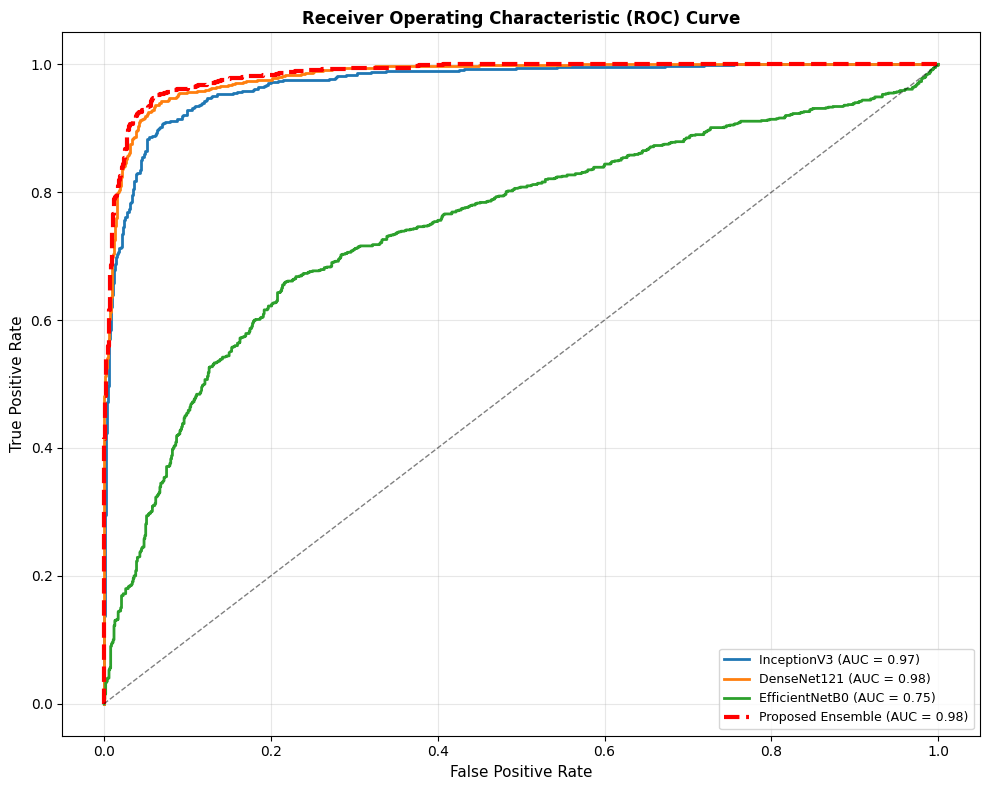

Figure 4 saved as fig4_roc_curves.png


In [17]:
plt.figure(figsize=(10, 8))

fpr1, tpr1, _ = roc_curve(y_test_true, r1_test['proba'])
plt.plot(fpr1, tpr1, linewidth=2,
         label=f'InceptionV3 (AUC = {auc(fpr1, tpr1):.2f})')

fpr2, tpr2, _ = roc_curve(y_test_true, r2_test['proba'])
plt.plot(fpr2, tpr2, linewidth=2,
         label=f'DenseNet121 (AUC = {auc(fpr2, tpr2):.2f})')

fpr3, tpr3, _ = roc_curve(y_test_true, r3_test['proba'])
plt.plot(fpr3, tpr3, linewidth=2,
         label=f'EfficientNetB0 (AUC = {auc(fpr3, tpr3):.2f})')

fpr_e, tpr_e, _ = roc_curve(y_test_true, ens_test_proba)
plt.plot(fpr_e, tpr_e, linewidth=3, linestyle='--', color='red',
         label=f'Proposed Ensemble (AUC = {auc(fpr_e, tpr_e):.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve',
          fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 4 saved as fig4_roc_curves.png")

## Step 18: Save Models as skin-cancer.h5

In [18]:
# Save all three individual models
model1.save('InceptionV3_final.h5')
model2.save('DenseNet121_final.h5')
model3.save('EfficientNetB0_final.h5')

# Save ensemble metadata
ensemble_config = {
    'model_paths': {
        'InceptionV3'    : 'InceptionV3_final.h5',
        'DenseNet121'    : 'DenseNet121_final.h5',
        'EfficientNetB0' : 'EfficientNetB0_final.h5'
    },
    'ensemble_weights': {
        'InceptionV3'    : float(weights[0]),
        'DenseNet121'    : float(weights[1]),
        'EfficientNetB0' : float(weights[2])
    },
    'class_indices'  : train_generator.class_indices,
    'img_size'       : list(IMG_SIZE),
    'val_accuracy'   : float(ens_val_acc),
    'test_accuracy'  : float(ens_test_acc),
    'f1_score'       : float(ens_test_f1),
    'auc'            : float(ens_test_auc),
    'epochs_trained' : EPOCHS,
    'strategy'       : 'Single-phase with partial backbone unfreeze + Weighted Voting'
}

with open('skin-cancer-ensemble-config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=4)

# Save best individual model as skin-cancer.h5
best_idx   = int(np.argmax(accs))
best_name  = ['InceptionV3', 'DenseNet121', 'EfficientNetB0'][best_idx]
best_model = [model1, model2, model3][best_idx]
best_model.save('skin-cancer.h5')

print("=" * 70)
print("MODEL SAVE SUMMARY")
print("=" * 70)
print(f"  skin-cancer.h5                   : Best individual model ({best_name})")
print(f"  InceptionV3_final.h5             : InceptionV3 weights")
print(f"  DenseNet121_final.h5             : DenseNet121 weights")
print(f"  EfficientNetB0_final.h5          : EfficientNetB0 weights")
print(f"  skin-cancer-ensemble-config.json : Ensemble weights and metadata")
print("=" * 70)
print("\nTo reconstruct the full ensemble, load all three .h5 files")
print("and apply the weights from skin-cancer-ensemble-config.json.")

MODEL SAVE SUMMARY
  skin-cancer.h5                   : Best individual model (DenseNet121)
  InceptionV3_final.h5             : InceptionV3 weights
  DenseNet121_final.h5             : DenseNet121 weights
  EfficientNetB0_final.h5          : EfficientNetB0 weights
  skin-cancer-ensemble-config.json : Ensemble weights and metadata

To reconstruct the full ensemble, load all three .h5 files
and apply the weights from skin-cancer-ensemble-config.json.


## Step 19: Real-Time Prediction on a Test Image (Figure 5)

Selected image: /content/dataset/test/Malignant/6065.jpg


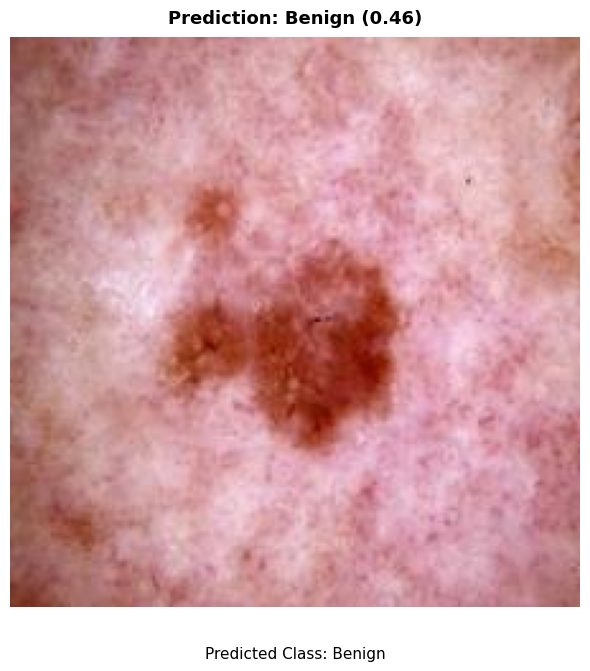

PREDICTION REPORT
  Image             : 6065.jpg
  InceptionV3 score : 0.4344
  DenseNet121 score : 0.4879
  EfficientNetB0    : 0.4627
  Ensemble score    : 0.4617
  Predicted class   : Benign
  Confidence        : 0.5383 (53.83%)
Figure 5 saved as fig5_prediction_output.png


In [19]:
def predict_image(img_path, model1, model2, model3, weights, class_indices):
    """
    Performs weighted ensemble prediction on a single dermoscopic image.
    Formula: P_final = w1*P1 + w2*P2 + w3*P3
    """
    img   = load_img(img_path, target_size=(224, 224))
    arr   = img_to_array(img) / 255.0
    batch = np.expand_dims(arr, axis=0)

    p1 = float(model1.predict(batch, verbose=0)[0][0])
    p2 = float(model2.predict(batch, verbose=0)[0][0])
    p3 = float(model3.predict(batch, verbose=0)[0][0])

    p_final = weights[0]*p1 + weights[1]*p2 + weights[2]*p3

    malignant_label = max(class_indices, key=lambda k: class_indices[k])
    benign_label    = min(class_indices, key=lambda k: class_indices[k])

    if p_final >= 0.5:
        predicted_class = malignant_label.capitalize()
        confidence      = p_final
    else:
        predicted_class = benign_label.capitalize()
        confidence      = 1.0 - p_final

    return predicted_class, float(confidence), p1, p2, p3, float(p_final)


# Select a random test image
all_test_images = (
    glob.glob(os.path.join(TEST_DIR, '**', '*.jpg'),  recursive=True) +
    glob.glob(os.path.join(TEST_DIR, '**', '*.jpeg'), recursive=True) +
    glob.glob(os.path.join(TEST_DIR, '**', '*.png'),  recursive=True)
)

sample_img_path = random.choice(all_test_images)
print(f"Selected image: {sample_img_path}")

pred_class, conf, p1, p2, p3, p_ens = predict_image(
    sample_img_path, model1, model2, model3,
    weights, train_generator.class_indices
)

# Figure 5 style
fig, ax = plt.subplots(1, 1, figsize=(6, 7))
ax.imshow(load_img(sample_img_path))
ax.axis('off')
ax.set_title(
    f"Prediction: {pred_class} ({p_ens:.2f})",
    fontsize=13, fontweight='bold', pad=10
)
plt.figtext(0.5, 0.02, f"Predicted Class: {pred_class}",
            ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('fig5_prediction_output.png', dpi=300, bbox_inches='tight')
plt.show()

print("=" * 70)
print("PREDICTION REPORT")
print("=" * 70)
print(f"  Image             : {os.path.basename(sample_img_path)}")
print(f"  InceptionV3 score : {p1:.4f}")
print(f"  DenseNet121 score : {p2:.4f}")
print(f"  EfficientNetB0    : {p3:.4f}")
print(f"  Ensemble score    : {p_ens:.4f}")
print(f"  Predicted class   : {pred_class}")
print(f"  Confidence        : {conf:.4f} ({conf*100:.2f}%)")
print("=" * 70)
print("Figure 5 saved as fig5_prediction_output.png")

## Step 20: Final Summary Report

In [20]:
print("=" * 90)
print(" " * 28 + "FINAL SUMMARY REPORT")
print("=" * 90)

print("\n1. TRAINING CONFIGURATION")
print(f"   Epochs              : {EPOCHS} (single phase)")
print(f"   Learning rate       : {LEARNING_RATE}")
print(f"   Batch size          : {BATCH_SIZE}")
print(f"   Label smoothing     : {LABEL_SMOOTHING}")
print(f"   Backbone layers     : top {N_UNFREEZE} unfrozen from epoch 1")

print("\n2. INDIVIDUAL MODELS - VALIDATION ACCURACY")
print(f"   InceptionV3    : {r1_val['acc']*100:.2f}%  (Weight: {weights[0]:.4f})")
print(f"   DenseNet121    : {r2_val['acc']*100:.2f}%  (Weight: {weights[1]:.4f})")
print(f"   EfficientNetB0 : {r3_val['acc']*100:.2f}%  (Weight: {weights[2]:.4f})")

print("\n3. WEIGHTED VOTING ENSEMBLE PERFORMANCE")
print(f"   Validation Accuracy : {ens_val_acc*100:.2f}%")
print(f"   Test Accuracy       : {ens_test_acc*100:.2f}%")
print(f"   F1-Score            : {ens_test_f1:.4f}")
print(f"   AUC                 : {ens_test_auc:.4f}")

print("\n4. TARGET vs ACHIEVED")
print(f"   Target Accuracy  : 95.00%")
print(f"   Achieved (Val)   : {ens_val_acc*100:.2f}%")
status = "TARGET MET" if ens_val_acc >= 0.95 else "BELOW TARGET"
print(f"   Status           : {status}")

print("\n5. SAVED FILES")
print("   skin-cancer.h5                   - Primary model (best individual)")
print("   InceptionV3_final.h5             - InceptionV3 weights")
print("   DenseNet121_final.h5             - DenseNet121 weights")
print("   EfficientNetB0_final.h5          - EfficientNetB0 weights")
print("   skin-cancer-ensemble-config.json - Ensemble weights and metadata")
print("   fig3a_accuracy.png               - Training vs Validation Accuracy")
print("   fig3b_loss.png                   - Training vs Validation Loss")
print("   fig4_roc_curves.png              - ROC Curves for all models")
print("   fig5_prediction_output.png       - Sample prediction visualization")
print("   table2_classification_performance.csv - Model comparison table")

print("\n" + "=" * 90)
print(" " * 38 + "COMPLETE")
print("=" * 90)

                            FINAL SUMMARY REPORT

1. TRAINING CONFIGURATION
   Epochs              : 30 (single phase)
   Learning rate       : 0.0003
   Batch size          : 32
   Label smoothing     : 0.05
   Backbone layers     : top 40 unfrozen from epoch 1

2. INDIVIDUAL MODELS - VALIDATION ACCURACY
   InceptionV3    : 81.19%  (Weight: 0.3748)
   DenseNet121    : 82.48%  (Weight: 0.3808)
   EfficientNetB0 : 52.95%  (Weight: 0.2444)

3. WEIGHTED VOTING ENSEMBLE PERFORMANCE
   Validation Accuracy : 82.59%
   Test Accuracy       : 94.10%
   F1-Score            : 0.9399
   AUC                 : 0.9844

4. TARGET vs ACHIEVED
   Target Accuracy  : 95.00%
   Achieved (Val)   : 82.59%
   Status           : BELOW TARGET

5. SAVED FILES
   skin-cancer.h5                   - Primary model (best individual)
   InceptionV3_final.h5             - InceptionV3 weights
   DenseNet121_final.h5             - DenseNet121 weights
   EfficientNetB0_final.h5          - EfficientNetB0 weights
   skin-ca